In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from energyflow import EFP
from energyflow import EFPSet
import sys
sys.path.append("/home/yfkahn/projects/aip-yfkahn/shared/jet_interpretability_diffusion/GenerativeModelsOnPhaseSpace-main/omnilearn_lightning")
import qspace
import pickle
from matplotlib.colors import LogNorm

In [2]:
def ThreeVecToFourVec(p3):
    E = torch.linalg.norm(p3,dim=-1,keepdim=True)
    p4 = torch.cat([E,p3],dim=-1)
    return np.array(p4)

def min_pairwise_dot(p4):                                                                                                                               
    """Min of E_i*E_j - p⃗_i·p⃗_j over all pairs, shape (NEvents,)."""                                                                                    
    E = p4[:, :, 0]                                          # (N, P)                                                                                   
    EiEj = E[:, :, None] * E[:, None, :]                     # (N, P, P)
    p3 = p4[:, :, 1:]
    dots = np.einsum('bid,bjd->bij', p3, p3)  # (N, P, P)                                                                           
    pipj = EiEj - dots                                       # (N, P, P)
    # Mask diagonal (self-pairs) with inf
    pipj[:, range(p4.shape[1]), range(p4.shape[1])] = float('inf')
    return pipj.min(axis=-1).min(axis=-1)         # (N,)

def make_mindot_hist(Pdat,Nbins=50,log=True):
    Ps = Pdat
    p4s = ThreeVecToFourVec(Ps)
    mindots = min_pairwise_dot(p4s)
    if log:
        mindots_hist, bins = np.histogram(np.log10(mindots),bins=Nbins,density=True)
    else:
        mindots_hist, bins = np.histogram(mindots,bins=Nbins,density=True)
    return mindots_hist, bins 

In [16]:
pspace_dat = torch.load("../../shared/intermediate_by_nbranch/ee2qqbar/ee2qqbar_S=2000GeV_a=0p1365_N=2000000_NBranch=16_Nparticles=18_p3_normalized.pt")
Ntot=pspace_dat.shape[0]
Nparticles=pspace_dat.shape[1]

In [17]:
qpath="/home/yfkahn/scratch/q_space_datasets/ee2qqbar_S=2000GeV_a=0p1365_N=2000000_NBranch=16_Nparticles=18_p3_normalized_T5000_tgaus0_fluff1/Q_checkpoints.npy"
qspace_dat=np.memmap(qpath,dtype="float32",mode="r",shape=(100,Ntot,Nparticles,3))
#qinit=torch.as_tensor(qspace_dat[0],dtype=torch.float64)
qeq=torch.as_tensor(qspace_dat[-1],dtype=torch.float64)
peq=qspace.qs_to_ps(qeq)

In [18]:
pgen=torch.load('/home/yfkahn/projects/aip-yfkahn/yfkahn/JetDiffusion/gen_events/qqbar_E2000_N18_tgaus0.pt')
label1='tgaus 0, 1.9M data, full'
pgen_new=torch.load('gen_events/qqbar_E2000_tgaus100_check_K9.pt')
label2='tgaus 100, 1.9M data, full'
#check that energy and momentum are conserved
print(pgen[:10].norm(dim=-1).sum(dim=-1))
print(pgen[:10].sum(dim=1))
print(pspace_dat[:10].sum(dim=1))

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000])
tensor([[ 0.0000e+00,  0.0000e+00, -5.9605e-08],
        [-4.4238e-08, -3.3528e-08,  4.7497e-08],
        [ 5.9605e-08,  1.8626e-09,  1.4901e-08],
        [-1.4901e-08,  6.1467e-08, -4.8429e-08],
        [-2.9802e-08, -1.4901e-08,  0.0000e+00],
        [ 0.0000e+00, -2.9802e-08,  4.4703e-08],
        [ 1.4901e-08,  1.3039e-08,  2.9802e-08],
        [-1.8626e-08,  1.4901e-08,  2.9802e-08],
        [ 1.3970e-08,  8.3819e-08, -5.5879e-08],
        [ 2.9802e-08,  2.9802e-08, -2.7008e-08]])
tensor([[ 3.7253e-08, -1.4901e-08,  7.4506e-09],
        [-1.2107e-08, -2.8522e-09,  2.1420e-08],
        [-7.4506e-09,  7.4506e-09, -7.4506e-09],
        [-1.8626e-09,  7.4506e-09, -2.9802e-08],
        [-9.3132e-10, -1.8626e-09,  4.4703e-08],
        [-6.9849e-10, -1.9558e-08, -7.4506e-09],
        [-1.9092e-08,  9.5461e-09, -2.8638e-08],
        [ 2.7940e-09, -7.4506e-09,  1.4901e-08],
        [ 2.2352e-08

In [19]:
p4s_true=ThreeVecToFourVec(pspace_dat[:10000])
mindots_true_hist, mindot_bins_true = make_mindot_hist(pspace_dat[:10000].to(torch.float64))
p4s_gen=ThreeVecToFourVec(pgen)
mindots_gen_hist, mindot_bins_gen = make_mindot_hist(pgen.to(torch.float64))
p4s_gen_new=ThreeVecToFourVec(pgen_new)
mindots_gen_new_hist, mindot_bins_gen_new = make_mindot_hist(pgen_new.to(torch.float64))
p4s_eq=ThreeVecToFourVec(peq[:10000])
mindots_eq_hist, mindot_bins_eq = make_mindot_hist(peq.to(torch.float64))

/tmp/ipykernel_1908436/2581210306.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(p4)


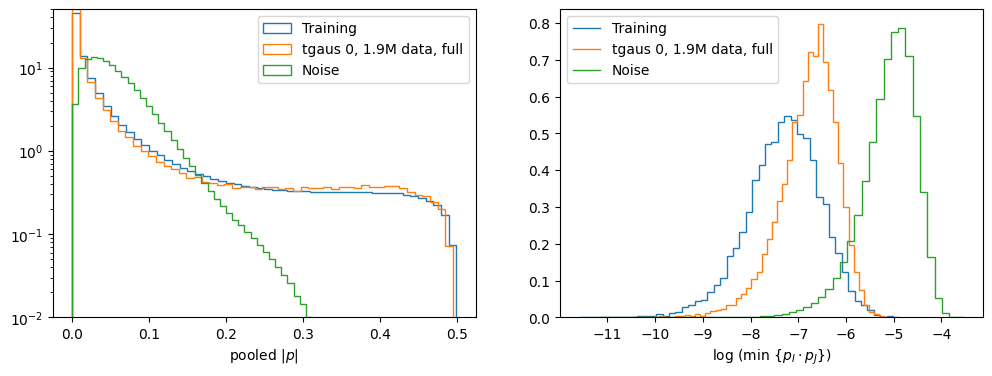

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pspace_dat[:500000].norm(dim=-1).flatten(),bins=50,histtype='step',density=True,label='Training')
axes[0].hist(pgen.norm(dim=-1).flatten(),bins=50,histtype='step',density=True,label=label1)
#axes[0].hist(pgen_new.norm(dim=-1).flatten(),bins=50,histtype='step',density=True,label=label2)
axes[0].hist(peq[:500000].norm(dim=-1).flatten(),bins=50,histtype='step',density=True,label='Noise')
axes[0].set_yscale('log')
axes[0].set_ylim((1e-2,50))
axes[0].set_xlabel(r'pooled $|p|$')
axes[0].legend()

axes[1].stairs(mindots_true_hist, mindot_bins_true,label='Training')
axes[1].stairs(mindots_gen_hist, mindot_bins_gen,label=label1)
#axes[1].stairs(mindots_gen_new_hist, mindot_bins_gen_new,label=label2)
axes[1].stairs(mindots_eq_hist, mindot_bins_eq,label=r'Noise')
#axes[1].set_yscale('log')
axes[1].set_xlabel(r'log (min $\{p_I \cdot p_J\}$)')
axes[1].legend(loc='upper left')

plt.show()

In [9]:
efpgraph_2pt = [(0,1), (0,1),(0,1)]
efpgraph_triangle = [(0,1), (0,2), (1,2)]
efpgraph_square_cross   = [(0,1), (1,2), (2,3), (3,1),(0,2),(1,3)]
EFP_2pt = EFP(efpgraph_2pt, measure='ee', beta=2, normed=True, coords='epxpypz')
EFP_triangle = EFP(efpgraph_triangle, measure='ee', beta=2, normed=True, coords='epxpypz')
EFP_square = EFP(efpgraph_square_cross, measure='ee', beta=2, normed=True, coords='epxpypz')

EFP_2pt_true=EFP_2pt.batch_compute(p4s_true[:50000])
EFP_2pt_gen=EFP_2pt.batch_compute(p4s_gen)
#EFP_2pt_gen_new=EFP_2pt.batch_compute(p4s_gen_new)
#EFP_2pt_eq=EFP_2pt.batch_compute(p4s_eq[:50000])

EFP_triangle_true=EFP_triangle.batch_compute(p4s_true[:50000])
EFP_triangle_gen=EFP_triangle.batch_compute(p4s_gen)
#EFP_triangle_gen_new=EFP_triangle.batch_compute(p4s_gen_new)
#EFP_triangle_eq=EFP_triangle.batch_compute(p4s_eq[:50000])

EFP_square_true=EFP_square.batch_compute(p4s_true[:50000])
EFP_square_gen=EFP_square.batch_compute(p4s_gen)
#EFP_square_gen_new=EFP_square.batch_compute(p4s_gen_new)
#EFP_square_eq=EFP_square.batch_compute(p4s_eq[:50000])

In [10]:
EFP_2pt_hist_true, bins_2pt_true = np.histogram(EFP_2pt_true,bins=50,density=True)
EFP_2pt_hist_gen, bins_2pt_gen = np.histogram(EFP_2pt_gen,bins=50,density=True)
#EFP_2pt_hist_gen_new, bins_2pt_gen_new = np.histogram(EFP_2pt_gen_new,bins=50,density=True)
#EFP_2pt_hist_eq, bins_2pt_eq = np.histogram(EFP_2pt_eq,bins=50,density=True)

EFP_triangle_hist_true, bins_triangle_true = np.histogram(EFP_triangle_true,bins=50,density=True)
EFP_triangle_hist_gen, bins_triangle_gen = np.histogram(EFP_triangle_gen,bins=50,density=True)
#EFP_triangle_hist_gen_new, bins_triangle_gen_new = np.histogram(EFP_triangle_gen_new,bins=50,density=True)
#EFP_triangle_hist_eq, bins_triangle_eq = np.histogram(EFP_triangle_eq,bins=50,density=True)

EFP_square_hist_true, bins_square_true = np.histogram(EFP_square_true,bins=50,density=True)
EFP_square_hist_gen, bins_square_gen = np.histogram(EFP_square_gen,bins=50,density=True)
#EFP_square_hist_gen_new, bins_square_gen_new = np.histogram(EFP_square_gen_new,bins=50,density=True)
#EFP_square_hist_eq, bins_square_eq = np.histogram(EFP_square_eq,bins=50,density=True)

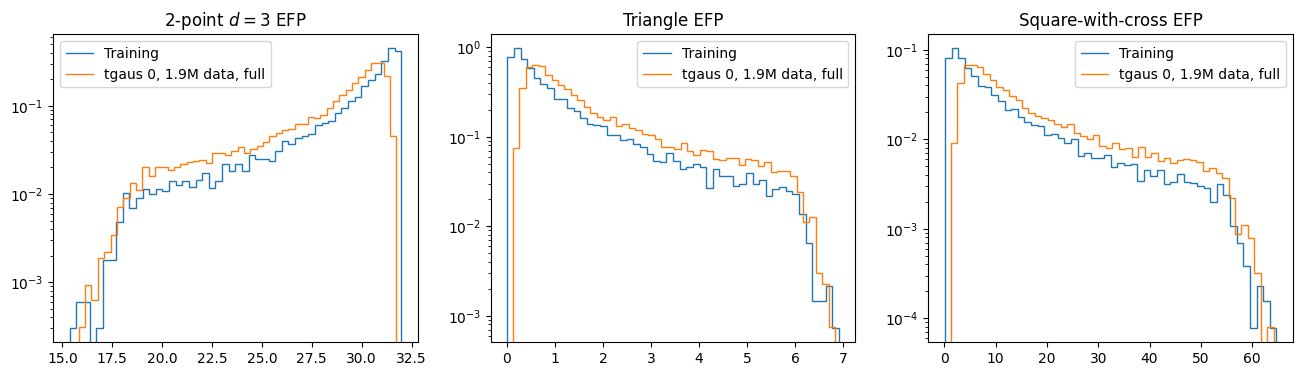

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))


axes[0].stairs(EFP_2pt_hist_true,bins_2pt_true,label='Training')
axes[0].stairs(EFP_2pt_hist_gen,bins_2pt_gen,label=label1)
#axes[0].stairs(EFP_2pt_hist_gen_new,bins_2pt_gen_new,label=label2)
#axes[0].stairs(EFP_2pt_hist_eq,bins_2pt_eq,label=r'Noise')
axes[0].set_yscale('log')
axes[0].set_title(r'2-point $d=3$ EFP')
axes[0].legend()

axes[1].stairs(EFP_triangle_hist_true,bins_triangle_true,label='Training')
axes[1].stairs(EFP_triangle_hist_gen,bins_triangle_gen,label=label1)
#axes[1].stairs(EFP_triangle_hist_gen_new,bins_triangle_gen_new,label=label2)
#axes[1].stairs(EFP_triangle_hist_eq,bins_triangle_eq,label=r'Noise')
axes[1].set_yscale('log')
axes[1].set_title(r'Triangle EFP')
axes[1].legend()

axes[2].stairs(EFP_square_hist_true,bins_square_true,label='Training')
axes[2].stairs(EFP_square_hist_gen,bins_square_gen,label=label1)
#axes[2].stairs(EFP_square_hist_gen_new,bins_square_gen_new,label=label2)
#axes[2].stairs(EFP_square_hist_eq,bins_square_eq,label=r'Noise')
axes[2].set_yscale('log')
axes[2].set_title(r'Square-with-cross EFP')
axes[2].legend()

plt.show()

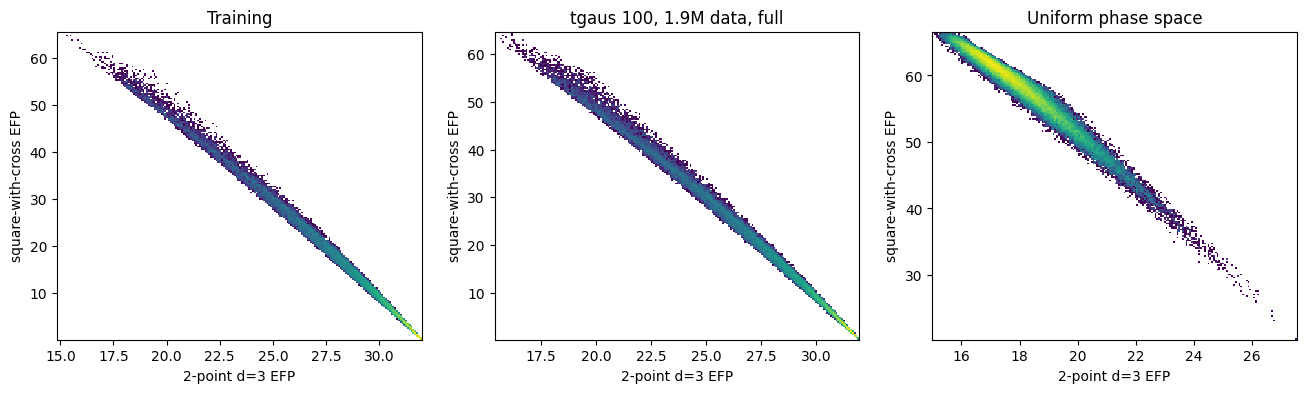

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist2d(EFP_2pt_true,EFP_square_true,bins=200,density=True,norm=LogNorm())
axes[0].set_title('Training')
axes[1].hist2d(EFP_2pt_gen_new,EFP_square_gen_new,bins=200,density=True,norm=LogNorm())
axes[1].set_title(label2)
axes[2].hist2d(EFP_2pt_eq,EFP_square_eq,bins=200,density=True,norm=LogNorm())
axes[2].set_title('Uniform phase space')
for ax in axes:
    ax.set_xlabel('2-point d=3 EFP')
    ax.set_ylabel('square-with-cross EFP')
plt.show()
